# Exploratory Data Analysis and Simple Linear Regression
This notebook demonstrates exploratory data analysis (EDA) and simple linear regression using a dataset on automobiles.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [2]:
GALLONS: str = 'GallonsPer100Miles'
MPG: str = 'MPG'
WEIGHT: str = 'Weight1000lb'
DISPLACEMENT: str = 'Displacement100ci'
HORSEPOWER: str = 'Horsepower100'
CYLINDERS: str = 'Cylinders'
SECONDS: str = "Seconds0to60"
YEAR: str = "Year"
ORIGIN: str = "Origin"

## Loading and Viewing the Dataset
Here, we load the dataset and display the first few rows to understand its structure.

In [3]:
df = pd.read_excel('autoMPG_data.xlsx')
df.head()

,GallonsPer100Miles,GallonsPer100MilesTo1981,MPG,Cylinders,Displacement100ci,Horsepower100,Weight1000lb,Seconds0to60,Year,Year70To81,Origin,Origin.Eq.1,Origin.Eq.2,Origin.Eq.3,Name
0,5.555556,5.555556,18.0,8,3.07,1.30,3.504,12.0,70,1,1,1,0,0,chevrolet chevelle malibu
1,6.666667,6.666667,15.0,8,3.50,1.65,3.693,11.5,70,1,1,1,0,0,buick skylark 320
2,5.555556,5.555556,18.0,8,3.18,1.50,3.436,11.0,70,1,1,1,0,0,plymouth satellite
3,6.250000,6.250000,16.0,8,3.04,1.50,3.433,12.0,70,1,1,1,0,0,amc rebel sst
4,5.882353,5.882353,17.0,8,3.02,1.40,3.449,10.5,70,1,1,1,0,0,ford torino


## Data cleaning
We clean the data by remove the model name because it doesn't help in determining fuel consumption. Next we remove GallonsPer100MilesTo1981 and Year 70 To 81 columns because they are redundant thanks to the GallonsPer100Miles and Year columns respectively. We remove Origin.Eq.1/2/3 as well as they are redundant because of Origin column. 

In [4]:
if "Name" in df.columns: df.drop(columns=["Name"], inplace=True)
if "GallonsPer100MilesTo1981" in df.columns: df.drop(columns=["GallonsPer100MilesTo1981"], inplace=True)
if "Year70To81" in df.columns: df.drop(columns=["Year70To81"], inplace=True)
if "Origin.Eq.1" in df.columns: df.drop(columns=["Origin.Eq.1"], inplace=True)
if "Origin.Eq.2" in df.columns: df.drop(columns=["Origin.Eq.2"], inplace=True)
if "Origin.Eq.3" in df.columns: df.drop(columns=["Origin.Eq.3"], inplace=True)

## Exploring Columns of Interest
We look at the minimum, maximum and average values of the columns to understand its range.

In [5]:
for col in df.columns:
    print(f"{col}: {min(df[col])} - {max(df[col])} (Average: {df[col].mean()})\n")
    
# Maybe remove the new line at the end, not sure which one looks better

GallonsPer100Miles: 2.1459227467811157 - 11.11111111111111 (Average: 4.782242789602456)

MPG: 9.0 - 46.6 (Average: 23.445918367346938)

Cylinders: 3 - 8 (Average: 5.471938775510204)

Displacement100ci: 0.68 - 4.55 (Average: 1.9441198979591838)

Horsepower100: 0.46 - 2.3 (Average: 1.0446938775510206)

Weight1000lb: 1.613 - 5.14 (Average: 2.977584183673469)

Seconds0to60: 8.0 - 24.8 (Average: 15.541326530612244)

Year: 70 - 82 (Average: 75.9795918367347)

Origin: 1 - 3 (Average: 1.5765306122448979)



## Visualizing Distributions
We create histograms to visualize the distributions of `Weight1000lb` and `MPG` columns.

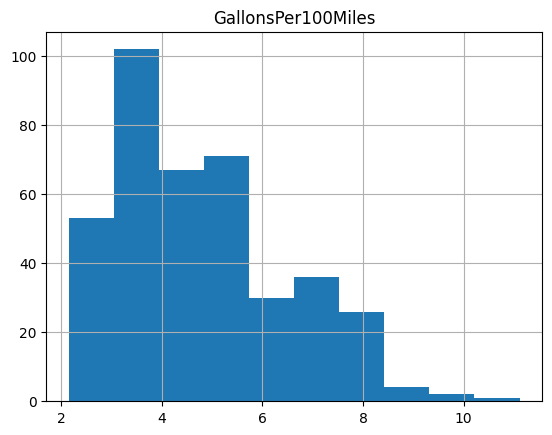

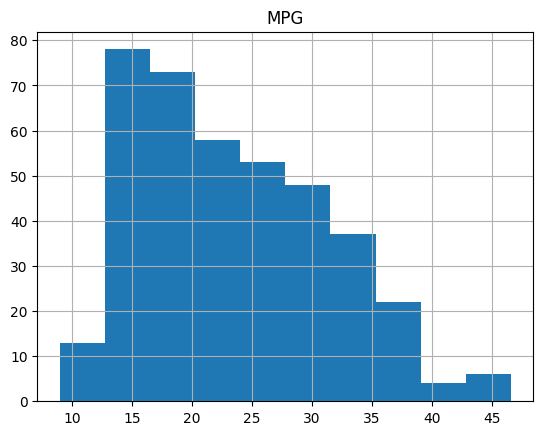

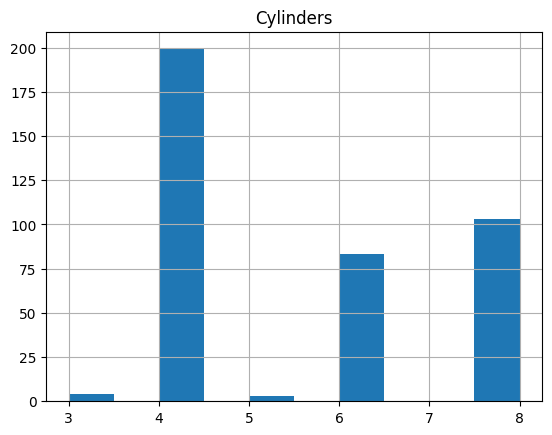

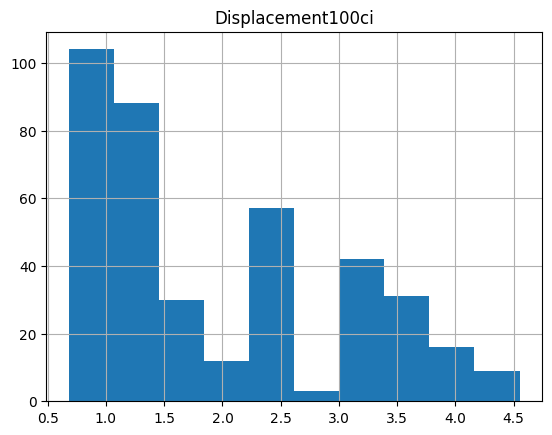

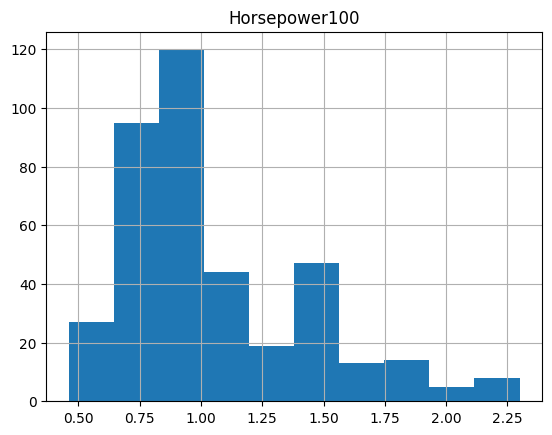

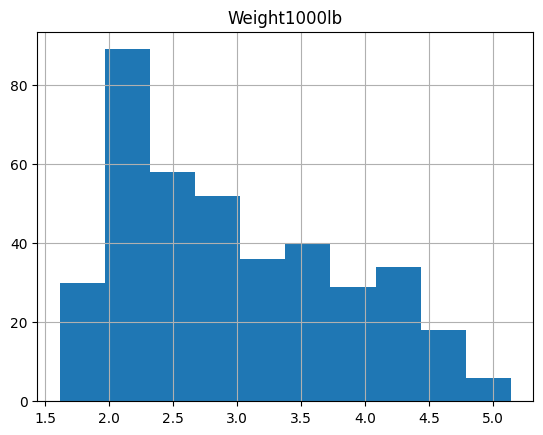

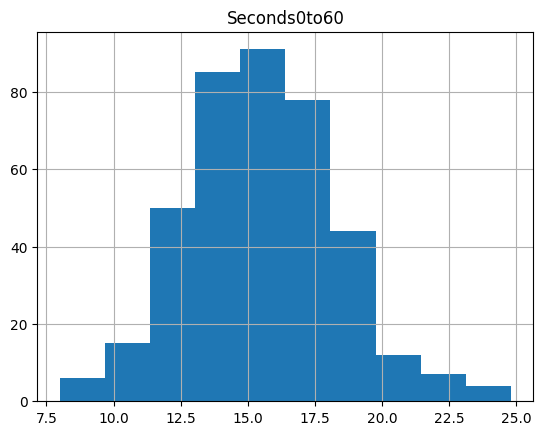

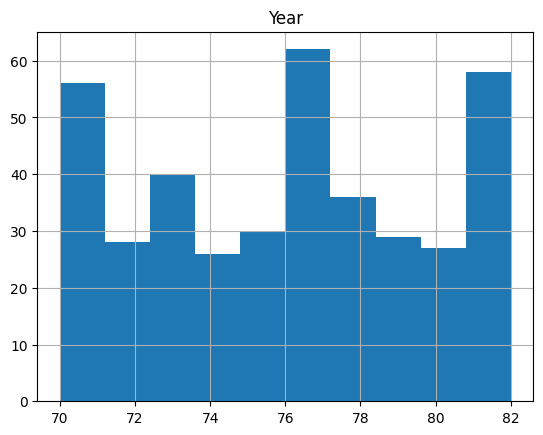

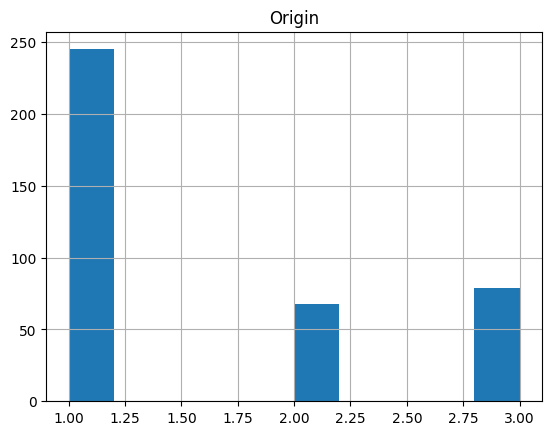

In [6]:
for col in df.columns:
    df[col].hist()
    plt.title(col)
    plt.show()

## Pairwise Relationships
We use `sns.pairplot` to explore pairwise relationships among all numerical columns.

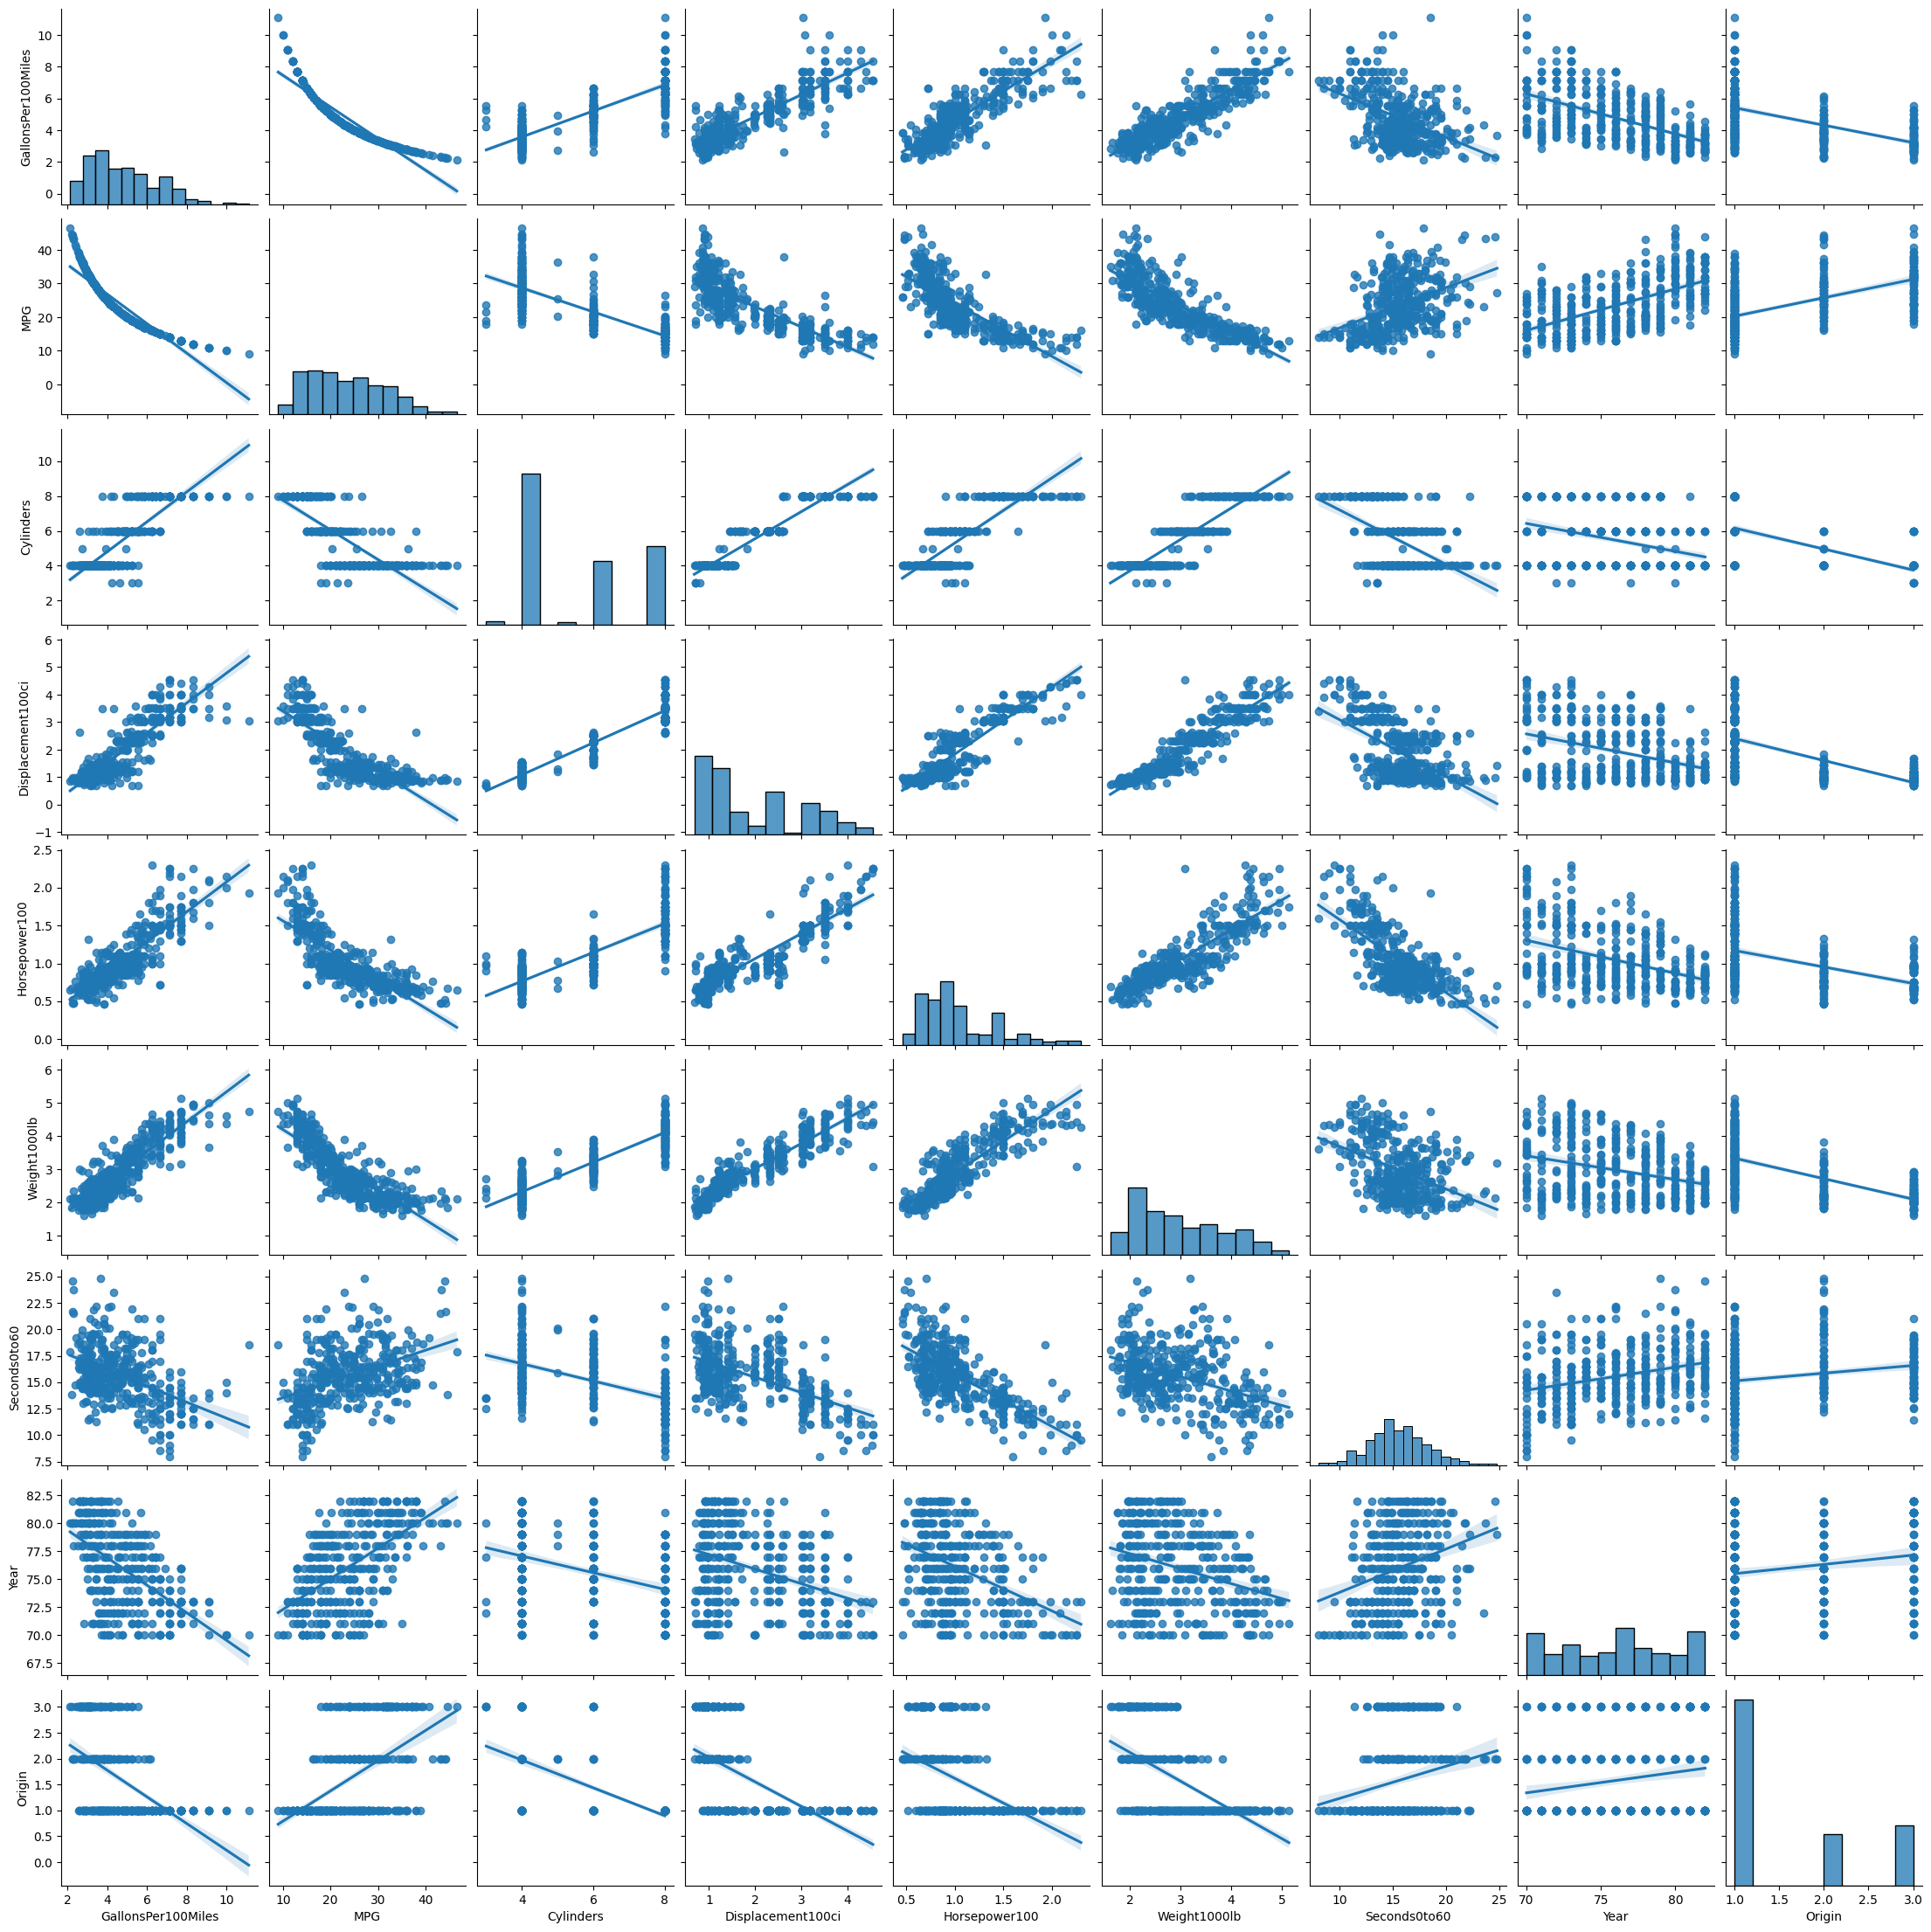

In [7]:
sns.pairplot(df, kind='reg')

## Correlation Analysis
Computing the correlation matrix.

In [8]:
df.corr()

,GallonsPer100Miles,MPG,Cylinders,Displacement100ci,Horsepower100,Weight1000lb,Seconds0to60,Year,Origin
GallonsPer100Miles,1.000000,-0.935935,0.839385,0.866050,0.854809,0.885056,-0.456338,-0.558255,-0.532932
MPG,-0.935935,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
Cylinders,0.839385,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
Displacement100ci,0.866050,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
Horsepower100,0.854809,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
Weight1000lb,0.885056,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
Seconds0to60,-0.456338,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
Year,-0.558255,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
Origin,-0.532932,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


## Visualizing Correlations
We use a heatmap to visualize the correlations between numerical columns.

<Axes: >

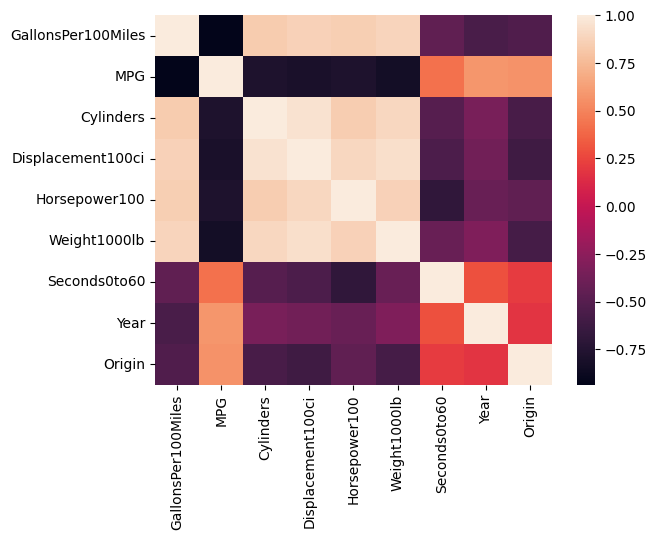

In [9]:
sns.heatmap(df.corr())

## Joint Distributions
Creating joint plots to explore relationships between key variables.

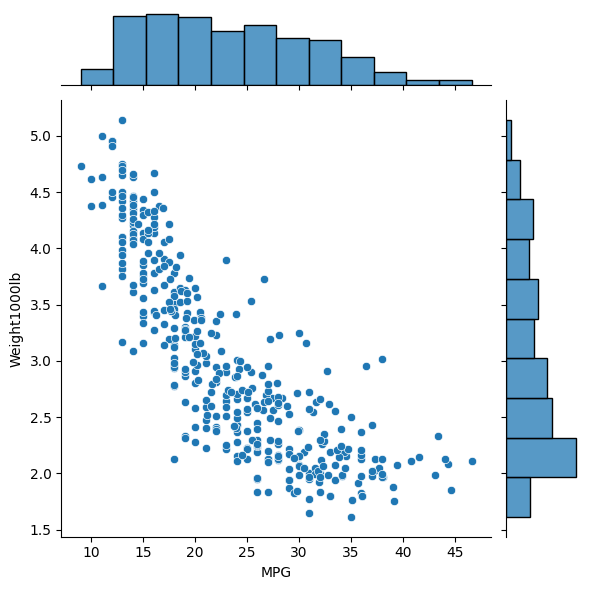

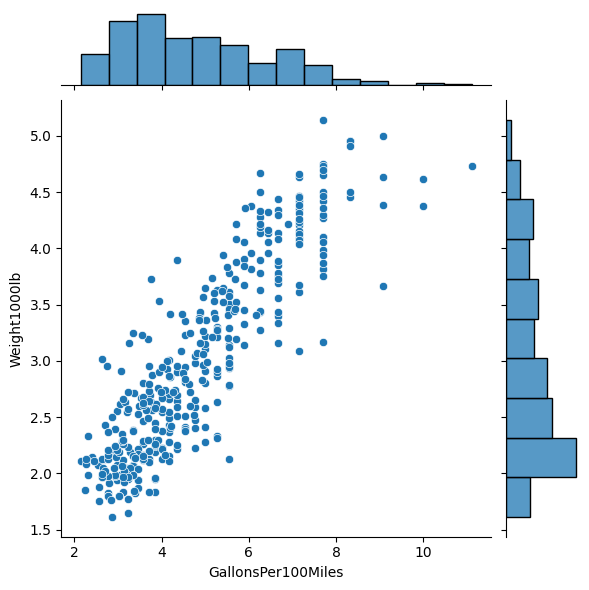

In [10]:
sns.jointplot(data=df, x=MPG, y=WEIGHT)
sns.jointplot(data=df, x=GALLONS, y=WEIGHT)

#### MPG vs. Weight (in 1000 lbs):

- Scatter Plot: Shows an expected negative correlation—heavier vehicles tend to have lower MPG, indicating reduced fuel efficiency as weight increases.
- Marginal Histograms: Highlight the most common ranges of MPG and Weight1000lb.

##### Gallons Per 100 Miles vs. Weight (in 1000 lbs):

- Scatter Plot: Demonstrates a positive correlation—heavier vehicles consume more fuel per 100 miles.
- Marginal Histograms: Show the distribution of GallonsPer100Miles and Weight1000lb.

Both plots confirm intuitive relationships between vehicle weight and fuel efficiency/consumption.

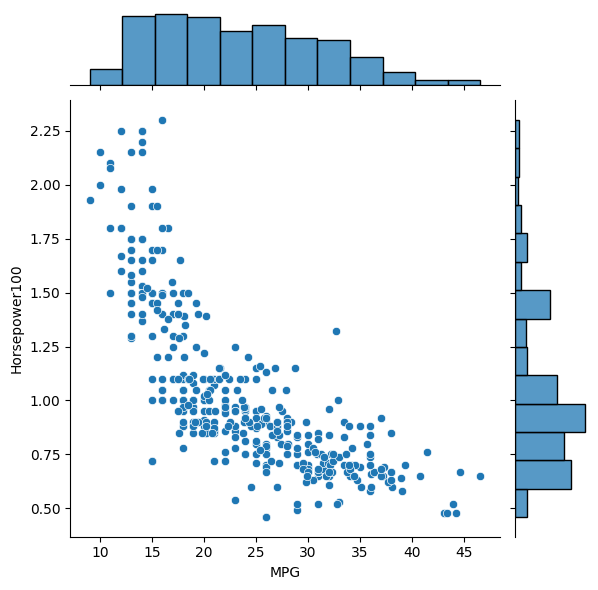

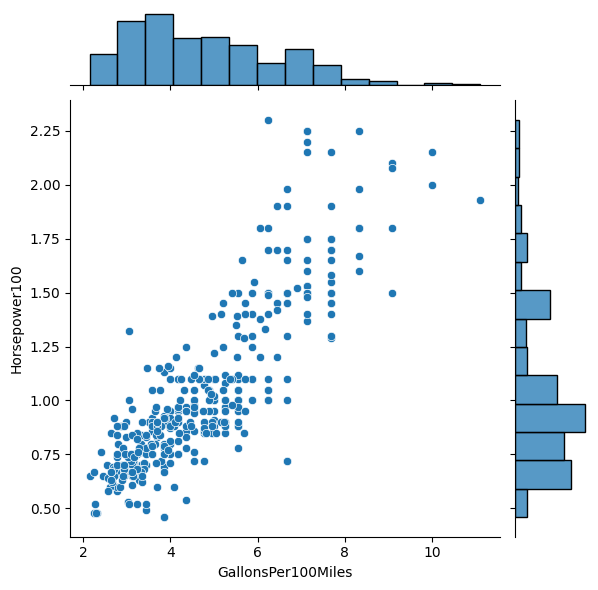

In [11]:
sns.jointplot(data=df, x=MPG, y=HORSEPOWER)
sns.jointplot(data=df, x=GALLONS, y=HORSEPOWER)

#### MPG vs. Horsepower (in 100):

- Scatter Plot: Shows an expected negative correlation — vehicles with higher horsepower tend to have lower MPG, indicating reduced fuel efficiency as horsepower increases.
- Marginal Histograms: Highlight the most common ranges of MPG and Horsepower.

##### Gallons Per 100 Miles vs. Horsepower (in 100):

- Scatter Plot: Demonstrates a positive correlation — vehicles with higher horsepower consume more fuel per 100 miles.
- Marginal Histograms: Show the distribution of GallonsPer100Miles and Horsepower.

Both plots confirm intuitive relationships between vehicle horsepower and fuel efficiency/consumption.

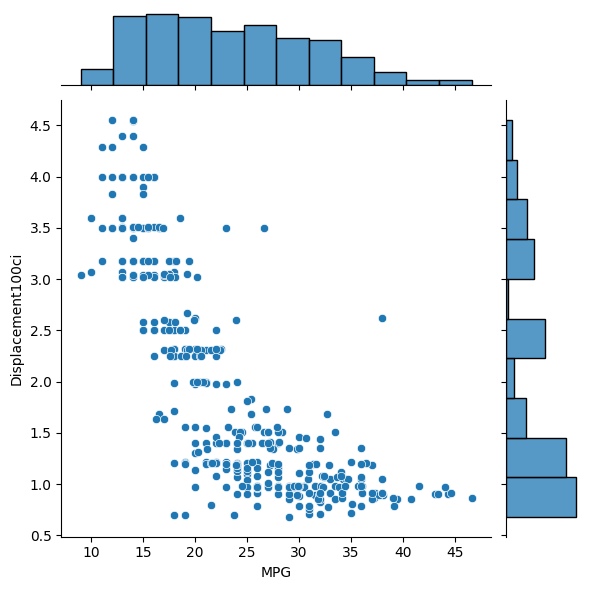

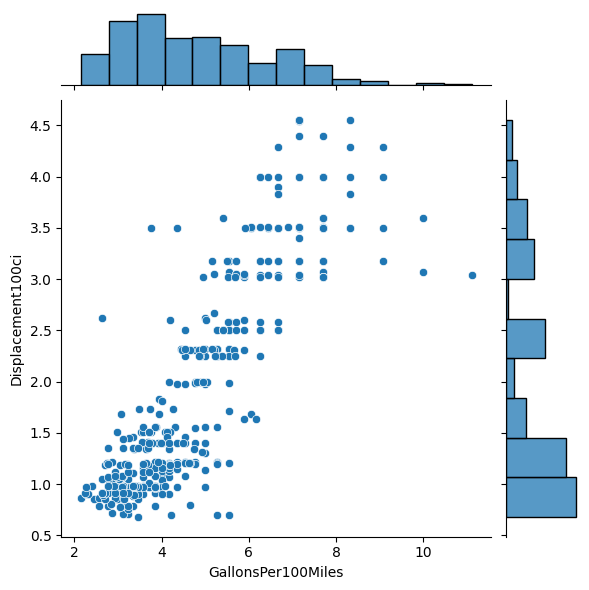

In [12]:
sns.jointplot(data=df, x=MPG, y=DISPLACEMENT)
sns.jointplot(data=df, x=GALLONS, y=DISPLACEMENT)

#### MPG vs. Displacement (in 100 cubic inches):

- Scatter Plot: Shows a negative correlation — vehicles with higher displacement tend to have lower MPG expect for some outliers, indicating reduced fuel efficiency as displacement increases.
- Marginal Histograms: Highlight the most common ranges of MPG and Displacement.

##### Gallons Per 100 Miles vs. Displacement (in 100 cubic inches):

- Scatter Plot: Demonstrates a positive correlation — vehicles with higher displacement consume more fuel per 100 miles excluding few outliers.
- Marginal Histograms: Show the distribution of GallonsPer100Miles and Displacement.

Both plots mostly confirm intuitive relationships between displacement and fuel efficiency/consumption.

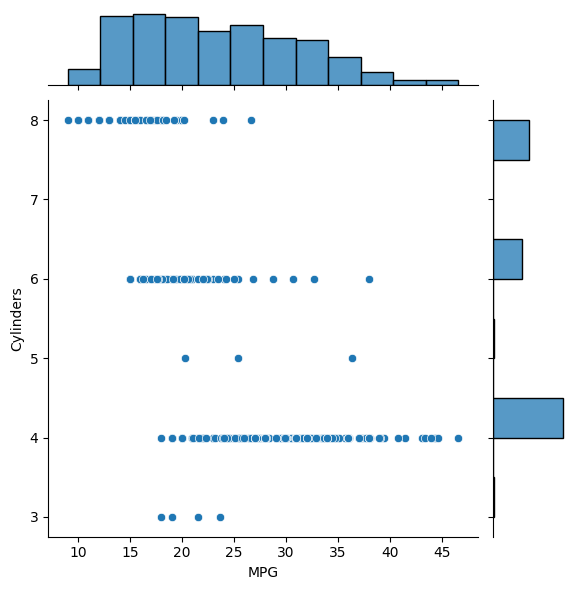

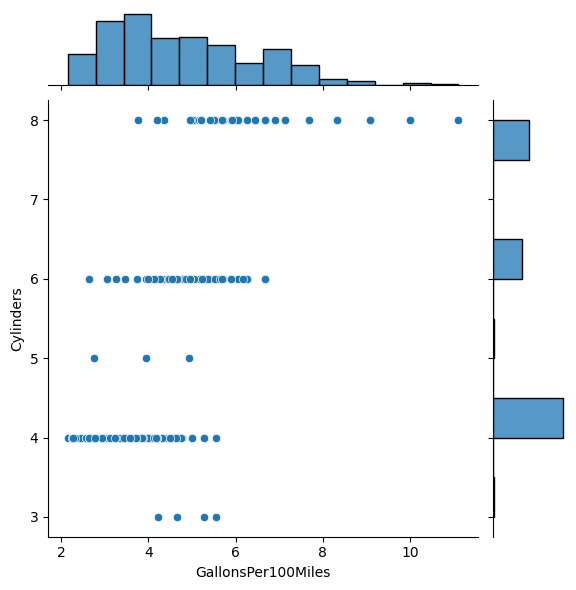

In [13]:
sns.jointplot(data=df, x=MPG, y=CYLINDERS)
sns.jointplot(data=df, x=GALLONS, y=CYLINDERS)

#### MPG vs. Cylinders:

- Scatter Plot: Shows negative correlattion - the less cylinders vehicle has more miles per gallon it can travel, however, the difference in distance is very persistent even for the same amount of cylinders.
- Marginal Histograms: Highlight the most common ranges of MPG and Cylinders.

##### Gallons Per 100 Miles vs. Displacement (in 100 cubic inches):

- Scatter Plot: Demonstrates a positive correlation — vehicles with more cylinders need more gallons per 100 miles. The gallon requirements get more sparsed the more cylinders we add.
- Marginal Histograms: Show the distribution of GallonsPer100Miles and Cylinders.

Both graph suffer from a wide range of data for certain amounts (MPG for 4 cylinders, 8 cylinders for GallonsPer100Miles)

### Conclussion of distributions

The values affecting MPG are Weight and Displacement, with Cylinders and Horsepower also play a role in the fuel requirements, however their role is a little bit smaller than the role of the beforehand-mentioned values.
GallonsPer100Miles are affect the most by Weight and Displacement. Horsepower and Cylinders follow shortly behind.

<Axes: >

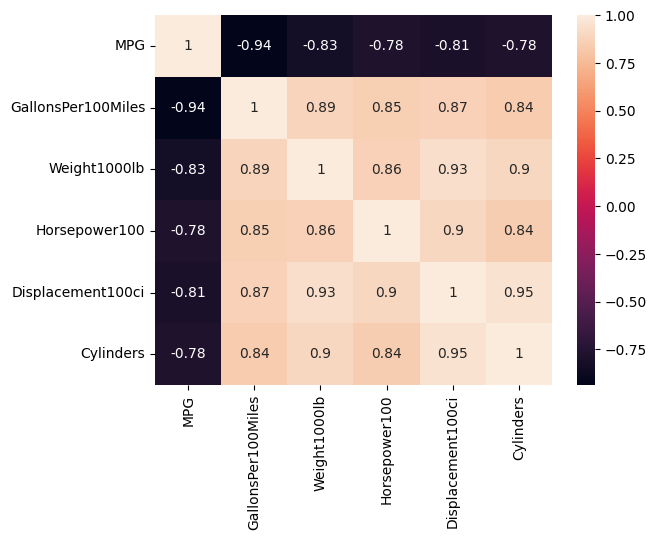

In [14]:
sns.heatmap(df[[MPG, GALLONS, WEIGHT, HORSEPOWER, DISPLACEMENT, CYLINDERS]].corr(), annot=True)

## Linear Regression Models
Building and evaluating a different linear regression models to compare them.

#### Visualization
- X-axis: Predicted values of GallonsPer100Miles (fuel_model.predict(X)).
- Y-axis: Residuals, calculated as the difference between predicted values and actual values (fuel_model.predict(X) - y).

- Residuals above this line indicate that the model over-predicted fuel consumption.
- Residuals below this line indicate that the model under-predicted fuel consumption.

In [34]:
DEPENDANT_VARIABLE = df[GALLONS]

models: dict[str, tuple[LinearRegression, float]] = {}

### Weight model

This model uses Weight values to estimate future fuel consumption.

In [35]:
x = df[WEIGHT].to_frame()
weight_model = LinearRegression().fit(x, DEPENDANT_VARIABLE)
weight_model.coef_, weight_model.intercept_

(array([1.73378735]), -0.3802549901551391)

- For every additional 1000 lbs in vehicle weight, the fuel consumption (GallonsPer100Miles) increases by approximately 1.73 gallons per 100 miles.
- Practical Meaning: Heavier vehicles are less fuel-efficient and require more fuel for the same distance.
- Value of GallonsPer100Miles would be -0.38 if the weight of the vehicle was 0 lbs.

### Prediction
For 1000 lb, 3000 lb and 10000 lbs

In [36]:
print(f"Weight 1000 lbs: {round(weight_model.predict(pd.DataFrame([1]))[0], 2)} gallons per 100 miles")
print(f"Weight 3000 lbs: {round(weight_model.predict(pd.DataFrame([3]))[0], 2)} gallons per 100 miles")
print(f"Weight 10000 lbs: {round(weight_model.predict(pd.DataFrame([10]))[0], 2)} gallons per 100 miles")

Weight 1000 lbs: 1.35 gallons per 100 miles
Weight 3000 lbs: 4.82 gallons per 100 miles
Weight 10000 lbs: 16.96 gallons per 100 miles


c:\Users\spasi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\spasi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\spasi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


#### Visualization

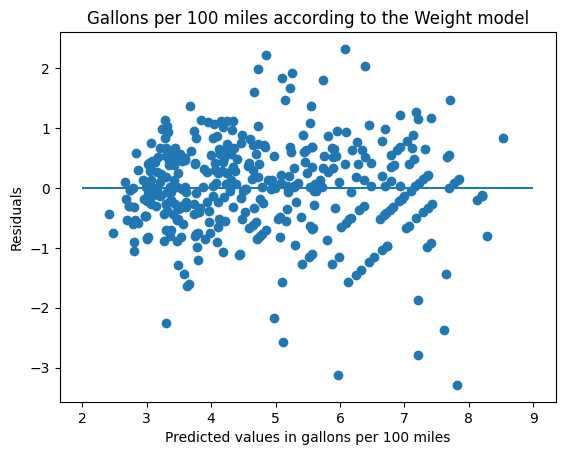

In [37]:
plt.scatter(weight_model.predict(x), weight_model.predict(x) - DEPENDANT_VARIABLE)
plt.hlines(y=0, xmin=2, xmax=9)
plt.title("Gallons per 100 miles according to the Weight model")
plt.xlabel("Predicted values in gallons per 100 miles")
plt.ylabel("Residuals")
plt.show()

- The residuals are distributed around the horizontal line at 𝑦=0, with no obvious pattern. This suggests the model reasonably fits the data.
- Most residuals are close to zero, indicating that the predictions are generally accurate.
- Larger residuals (points farther from the line) indicate instances where the model's predictions deviate more significantly from actual values.
- There is no clear curve or systematic trend in the residuals, supporting the assumption of linearity.
- Points significantly above or below the line might be outliers or instances where the model underperforms.

#### Accuracy

In [38]:
accuracy = round(weight_model.score(x, DEPENDANT_VARIABLE) * 100, 2)
models[WEIGHT] = (weight_model, accuracy)
print(f"{accuracy}%")

78.33%


- Approximately 78.33% of the variability in the target variable (GallonsPer100Miles) can be explained by the predictor variable (Weight1000lb).

### Horsepower model

This model uses Horsepower values to estimate future fuel consumption.

In [39]:
x = df[HORSEPOWER].to_frame()
horsepower_model = LinearRegression().fit(x, DEPENDANT_VARIABLE)
horsepower_model.coef_, horsepower_model.intercept_

(array([3.69527283]), 0.9218138877684923)

- For every additional 100 horsepower in vehicle, the fuel consumption (GallonsPer100Miles) increases by approximately 3.7 gallons per 100 miles.
- Practical Meaning: Vehicles with more horsepower are less fuel-efficient and require more fuel for the same distance.
- According to the model, value of GallonsPer100Miles would be 0.92 if the vehicle didn't have any horsepower.

### Prediction
For 100 horsepower, 200 horsepower and 400 horsepower

In [40]:
print(f"100 horsepower: {round(horsepower_model.predict(pd.DataFrame([1]))[0], 2)} gallons per 100 miles")
print(f"200 horsepower: {round(horsepower_model.predict(pd.DataFrame([3]))[0], 2)} gallons per 100 miles")
print(f"400 horsepower: {round(horsepower_model.predict(pd.DataFrame([10]))[0], 2)} gallons per 100 miles")

100 horsepower: 4.62 gallons per 100 miles
200 horsepower: 12.01 gallons per 100 miles
400 horsepower: 37.87 gallons per 100 miles


c:\Users\spasi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\spasi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\spasi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


#### Visualization


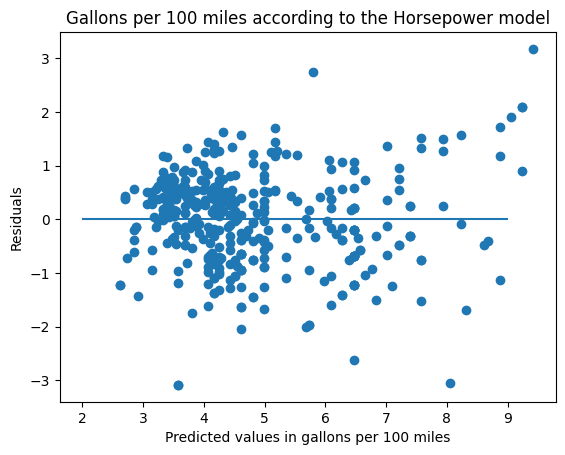

In [41]:
plt.scatter(horsepower_model.predict(x), horsepower_model.predict(x) - DEPENDANT_VARIABLE)
plt.hlines(y=0, xmin=2, xmax=9)
plt.title("Gallons per 100 miles according to the Horsepower model")
plt.xlabel("Predicted values in gallons per 100 miles")
plt.ylabel("Residuals")
plt.show()

- The residuals are distributed around the horizontal line at 𝑦=0, with no obvious pattern. This suggests the model reasonably fits the data.
- Most residuals are close to zero, indicating that the predictions are generally accurate.
- Larger residuals indicate instances where the model's predictions deviate more significantly from actual values.
- There is no clear curve or systematic trend in the residuals, supporting the assumption of linearity.
- Points significantly above or below the line might be outliers or instances where the model underperforms.

### Accuracy

In [42]:
accuracy = round(horsepower_model.score(x, DEPENDANT_VARIABLE) * 100, 2)
models[HORSEPOWER] = (horsepower_model, accuracy)
print(f"{accuracy}%")

73.07%


- Approximately 73.07% of the variability in the target variable (GallonsPer100Miles) can be explained by the predictor variable (Horsepower100).